In [ ]:
# Car Selling Price Prediction using Machine Learning

## ShadowFox AI/ML Internship Project

### Objective
To develop a machine learning model that predicts the selling price of used cars based on various features.

---

In [2]:
# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor

import joblib

In [3]:
df=pd.read_csv("car.csv")

df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [4]:
print(df.shape)

print(df.info())

print(df.isnull().sum())

print(df.duplicated().sum())

(301, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB
None
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64
2


In [5]:
df.drop_duplicates(inplace=True)

print(df.shape)

(299, 9)


In [6]:
df['Car_Age']=2026-df['Year']

df.drop('Year',axis=1,inplace=True)

df.head()

,Car_Name,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Car_Age
0,ritz,3.35,5.59,27000,Petrol,Dealer,Manual,0,12
1,sx4,4.75,9.54,43000,Diesel,Dealer,Manual,0,13
2,ciaz,7.25,9.85,6900,Petrol,Dealer,Manual,0,9
3,wagon r,2.85,4.15,5200,Petrol,Dealer,Manual,0,15
4,swift,4.60,6.87,42450,Diesel,Dealer,Manual,0,12


In [7]:
# label encoding remove one hot encoding applied
df=pd.get_dummies(df,drop_first=True)

df.head()

,Selling_Price,Present_Price,Kms_Driven,Owner,Car_Age,Car_Name_Activa 3g,Car_Name_Activa 4g,Car_Name_Bajaj ct 100,Car_Name_Bajaj Avenger 150,Car_Name_Bajaj Avenger 150 street,...,Car_Name_swift,Car_Name_sx4,Car_Name_verna,Car_Name_vitara brezza,Car_Name_wagon r,Car_Name_xcent,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
0,3.35,5.59,27000,0,12,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,True
1,4.75,9.54,43000,0,13,False,False,False,False,False,...,False,True,False,False,False,False,True,False,False,True
2,7.25,9.85,6900,0,9,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,True
3,2.85,4.15,5200,0,15,False,False,False,False,False,...,False,False,False,False,True,False,False,True,False,True
4,4.60,6.87,42450,0,12,False,False,False,False,False,...,True,False,False,False,False,False,True,False,False,True


In [8]:
df = pd.get_dummies(df, drop_first=True)

In [9]:
# Features and Target

X = df.drop('Selling_Price', axis=1)
y = df['Selling_Price']

print(X.shape)
print(y.shape)

(299, 105)
(299,)


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(239, 105)
(60, 105)


In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        random_state=42
    )
}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    print(name, "R2 Score :", round(r2_score(y_test, pred),4))

Linear Regression R2 Score : 0.3391
Random Forest R2 Score : 0.6008
Gradient Boosting R2 Score : 0.7049


In [12]:
# Extract Brand Name

df = pd.read_csv("car.csv")

df.drop_duplicates(inplace=True)

df['Car_Age'] = 2026 - df['Year']

df['Brand'] = df['Car_Name'].apply(lambda x: x.split()[0])

df.drop(['Car_Name','Year'],axis=1,inplace=True)

df.head()

,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Car_Age,Brand
0,3.35,5.59,27000,Petrol,Dealer,Manual,0,12,ritz
1,4.75,9.54,43000,Diesel,Dealer,Manual,0,13,sx4
2,7.25,9.85,6900,Petrol,Dealer,Manual,0,9,ciaz
3,2.85,4.15,5200,Petrol,Dealer,Manual,0,15,wagon
4,4.60,6.87,42450,Diesel,Dealer,Manual,0,12,swift


In [13]:
df = pd.get_dummies(
    df,
    columns=['Brand','Fuel_Type','Seller_Type','Transmission'],
    drop_first=True
)

df.head()

,Selling_Price,Present_Price,Kms_Driven,Owner,Car_Age,Brand_Activa,Brand_Bajaj,Brand_Hero,Brand_Honda,Brand_Hyosung,...,Brand_swift,Brand_sx4,Brand_verna,Brand_vitara,Brand_wagon,Brand_xcent,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
0,3.35,5.59,27000,0,12,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,True
1,4.75,9.54,43000,0,13,False,False,False,False,False,...,False,True,False,False,False,False,True,False,False,True
2,7.25,9.85,6900,0,9,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,True
3,2.85,4.15,5200,0,15,False,False,False,False,False,...,False,False,False,False,True,False,False,True,False,True
4,4.60,6.87,42450,0,12,False,False,False,False,False,...,True,False,False,False,False,False,True,False,False,True


In [14]:
X = df.drop('Selling_Price',axis=1)

y = df['Selling_Price']

print(X.shape)

print(y.shape)

(299, 51)
(299,)


In [15]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [16]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import r2_score

models = {
    "Linear":LinearRegression(),
    "Random Forest":RandomForestRegressor(
        n_estimators=300,
        random_state=42
    ),
    "Gradient Boosting":GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        random_state=42
    )
}

for name,model in models.items():
    model.fit(X_train,y_train)

    pred=model.predict(X_test)

    print(name,"R2 =",round(r2_score(y_test,pred),4))

Linear R2 = 0.5517
Random Forest R2 = 0.5774
Gradient Boosting R2 = 0.7242


In [17]:
# Final Model

final_model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    random_state=42
)

final_model.fit(X_train, y_train)

y_pred = final_model.predict(X_test)

In [18]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

print("R2 Score :", r2_score(y_test, y_pred))
print("MAE :", mean_absolute_error(y_test, y_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred)))

R2 Score : 0.7241675360087526
MAE : 1.1436405665445135
RMSE : 2.666290011204349


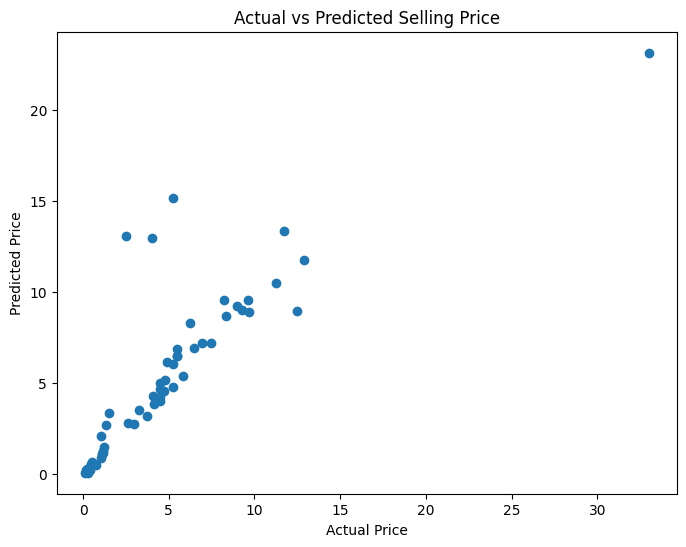

In [19]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Selling Price")
plt.show()

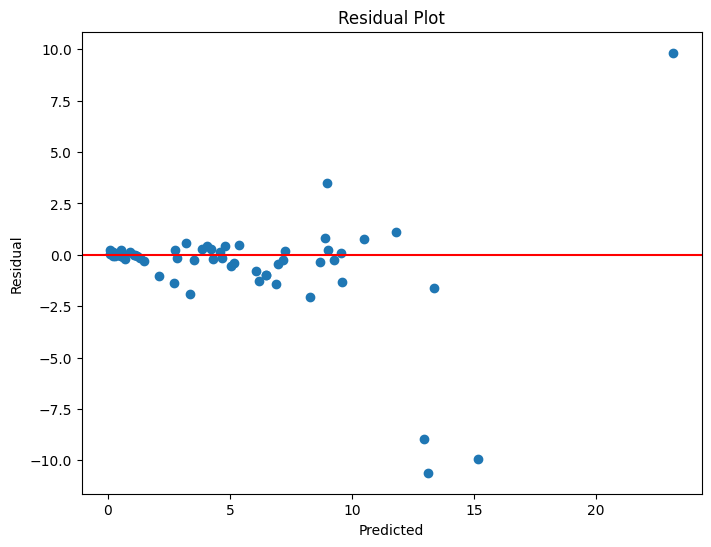

In [20]:
residuals = y_test - y_pred

plt.figure(figsize=(8,6))
plt.scatter(y_pred, residuals)
plt.axhline(y=0,color='red')
plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.show()

In [21]:
importance = pd.DataFrame({
    'Feature':X.columns,
    'Importance':final_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance.head(10))

                Feature  Importance
0         Present_Price    0.871736
3               Car_Age    0.077202
37           Brand_land    0.025906
1            Kms_Driven    0.008452
50  Transmission_Manual    0.007017
47     Fuel_Type_Diesel    0.005802
48     Fuel_Type_Petrol    0.001981
43          Brand_verna    0.000382
30       Brand_fortuner    0.000216
26        Brand_elantra    0.000152


In [22]:
import joblib

joblib.dump(final_model,'car_price_model.pkl')

print("Model Saved Successfully!")

Model Saved Successfully!


In [23]:
sample = X_test.iloc[0:1]

prediction = final_model.predict(sample)

print("Predicted Selling Price :", prediction[0])
print("Actual Selling Price :", y_test.iloc[0])

Predicted Selling Price : 9.26257397549257
Actual Selling Price : 8.99
